# 3D 视觉与 NeRF

> **斯坦福 CS231n** | 3D Vision and Neural Radiance Fields

## 本章导读

3D 视觉是从 2D 图像恢复 3D 结构的任务。NeRF 用神经网络表示 3D 场景，通过体渲染从任意视角生成新视图。本节从 3D 表示到 NeRF 完整路径。

**学习目标：**
- 理解 3D 表示方法（体素、点云、网格）
- 理解 NeRF 的核心思想
- 实现位置编码（Positional Encoding）
- 手算体渲染方程
- 实现简化 NeRF MLP

**参考来源：** [NeRF Paper](https://arxiv.org/abs/2003.08934) | [NeRF Studio](https://docs.nerf.studio/) | [CS231n](https://cs231n.stanford.edu/)

## 1. 直觉理解：3D 表示方法

### 三种 3D 表示

| 表示 | 数据结构 | 优点 | 缺点 |
|------|----------|------|------|
| **体素** | 3D 网格 | 规则、卷积友好 | 内存大、分辨率低 |
| **点云** | N 个 3D 点 | 紧凑、灵活 | 无拓扑、卷积难 |
| **网格** | 顶点+面片 | 精确表面 | 渲染复杂、拓扑约束 |

### NeRF 的第四种方式

NeRF (Neural Radiance Field) 用**神经网络隐式表示** 3D 场景：
- 输入：3D 位置 $(x, y, z)$ + 观察方向 $(\theta, \phi)$
- 输出：颜色 $(r, g, b)$ + 体密度 $\sigma$
- 整个场景编码在网络的权重中

[[Mildenhall et al., 2020]](https://arxiv.org/abs/2003.08934)

## 2. 体渲染方程

### NeRF 的渲染过程

给定相机光线 $\mathbf{r}(t) = \mathbf{o} + t\mathbf{d}$（原点 $\mathbf{o}$，方向 $\mathbf{d}$）：

$$C(\mathbf{r}) = \int_{t_n}^{t_f} T(t) \sigma(\mathbf{r}(t)) \mathbf{c}(\mathbf{r}(t), \mathbf{d}) \, dt$$

其中：
$$T(t) = \exp\left(-\int_{t_n}^{t} \sigma(\mathbf{r}(s)) \, ds\right)$$

- $T(t)$：从 $t_n$ 到 $t$ 的透射率（累积透明度）
- $\sigma(\mathbf{r}(t))$：体密度（不透明度）
- $\mathbf{c}$：颜色

### 离散化

$$\hat{C}(\mathbf{r}) = \sum_{i=1}^{N} T_i \alpha_i \mathbf{c}_i$$

其中：
$$T_i = \exp\left(-\sum_{j=1}^{i-1} \sigma_j \delta_j\right), \quad \alpha_i = 1 - \exp(-\sigma_i \delta_i)$$

$\delta_i = t_{i+1} - t_i$ 是相邻采样点间距。

## 3. 手算验证：体渲染

### 简化手算

设光线采样 3 个点，间距 $\delta = 1$：

| 点 $i$ | 体密度 $\sigma_i$ | 颜色 $\mathbf{c}_i$ |
|---------|-------------------|---------------------|
| 1 | 0.5 | [1, 0, 0] |
| 2 | 1.0 | [0, 1, 0] |
| 3 | 0.3 | [0, 0, 1] |

**计算：**

1. $\alpha_1 = 1 - \exp(-\sigma_1 \delta_1) = 1 - e^{-0.5} = 1 - 0.607 = 0.393$
2. $\alpha_2 = 1 - \exp(-1.0 \times 1) = 1 - e^{-1} = 0.632$
3. $\alpha_3 = 1 - \exp(-0.3 \times 1) = 1 - e^{-0.3} = 0.259$

**透射率：**
1. $T_1 = 1$（从起点开始，无衰减）
2. $T_2 = \exp(-\sigma_1 \delta_1) = e^{-0.5} = 0.607$
3. $T_3 = \exp(-(\sigma_1 + \sigma_2) \times 1) = e^{-1.5} = 0.223$

**颜色：**
$$\hat{C} = T_1 \alpha_1 \mathbf{c}_1 + T_2 \alpha_2 \mathbf{c}_2 + T_3 \alpha_3 \mathbf{c}_3$$
$$= 1 \times 0.393 \times [1,0,0] + 0.607 \times 0.632 \times [0,1,0] + 0.223 \times 0.259 \times [0,0,1]$$
$$= [0.393, 0, 0] + [0, 0.384, 0] + [0, 0, 0.058]$$
$$= [0.393, 0.384, 0.058]$$

颜色以红色和绿色为主，蓝色贡献最小（因为点 3 被前面的点遮挡）。

In [5]:
# Verify volume rendering
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
np.random.seed(42)

def volume_render(sigmas, colors, deltas):
    """Volume rendering equation.
    
    Args:
        sigmas: (N,) volume density at each point
        colors: (N, 3) RGB color at each point
        deltas: (N,) distance between adjacent samples
    
    Returns:
        rendered_color: (3,) RGB color
    """
    N = len(sigmas)
    # Alpha (opacity) at each point
    alphas = 1 - np.exp(-sigmas * deltas)
    
    # Transmittance (cumulative)
    T = np.ones(N)
    for i in range(1, N):
        T[i] = T[i-1] * np.exp(-sigmas[i-1] * deltas[i-1])
    
    # Rendered color
    weights = T * alphas  # (N,)
    rendered = np.sum(weights[:, None] * colors, axis=0)
    
    return rendered, weights

# Verify manual calculation
sigmas = np.array([0.5, 1.0, 0.3])
colors = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]], dtype=float)
deltas = np.array([1.0, 1.0, 1.0])

rendered, weights = volume_render(sigmas, colors, deltas)
print(f"Alphas: {1 - np.exp(-sigmas * deltas)}")
print(f"Transmittance: {weights / (1 - np.exp(-sigmas * deltas))}")
print(f"Weights: {weights}")
print(f"Rendered color: {rendered}")
print(f"Expected: [0.393, 0.384, 0.058]")
assert np.allclose(rendered, [0.393, 0.384, 0.058], atol=0.01), "Mismatch!"
print("Volume rendering verified!")

Alphas: [0.39346934 0.63212056 0.25918178]
Transmittance: [1.         0.60653066 0.22313016]
Weights: [0.39346934 0.3834005  0.05783127]
Rendered color: [0.39346934 0.3834005  0.05783127]
Expected: [0.393, 0.384, 0.058]
Volume rendering verified!


## 4. 位置编码（Positional Encoding）

### 原理

NeRF 使用位置编码将低维坐标映射到高维空间，使网络能拟合高频细节：

$$\gamma(x) = \left(x, \sin(2^0 \pi x), \cos(2^0 \pi x), \sin(2^1 \pi x), \cos(2^1 \pi x), \ldots, \sin(2^{L-1} \pi x), \cos(2^{L-1} \pi x)\right)$$

### 为什么需要位置编码？

MLP 倾向于学习低频函数（Rahaman et al., 2019）。位置编码通过将坐标映射到高频空间，使网络能学习高频细节（如锐利边缘、纹理）。

[[Vaswani et al., 2017]](https://arxiv.org/abs/1706.03762) 在 Transformer 中首次使用位置编码。
[[Tancik et al., 2020]](https://arxiv.org/abs/2006.10739) 分析了位置编码的 Fourier 特征。

Input shape: (100, 1)
Encoded (L=2): (100, 5) (1 + 2*2 = 5 dims per input)
Encoded (L=10): (100, 21) (1 + 2*10 = 21 dims per input)
Visualization 1: Positional encoding


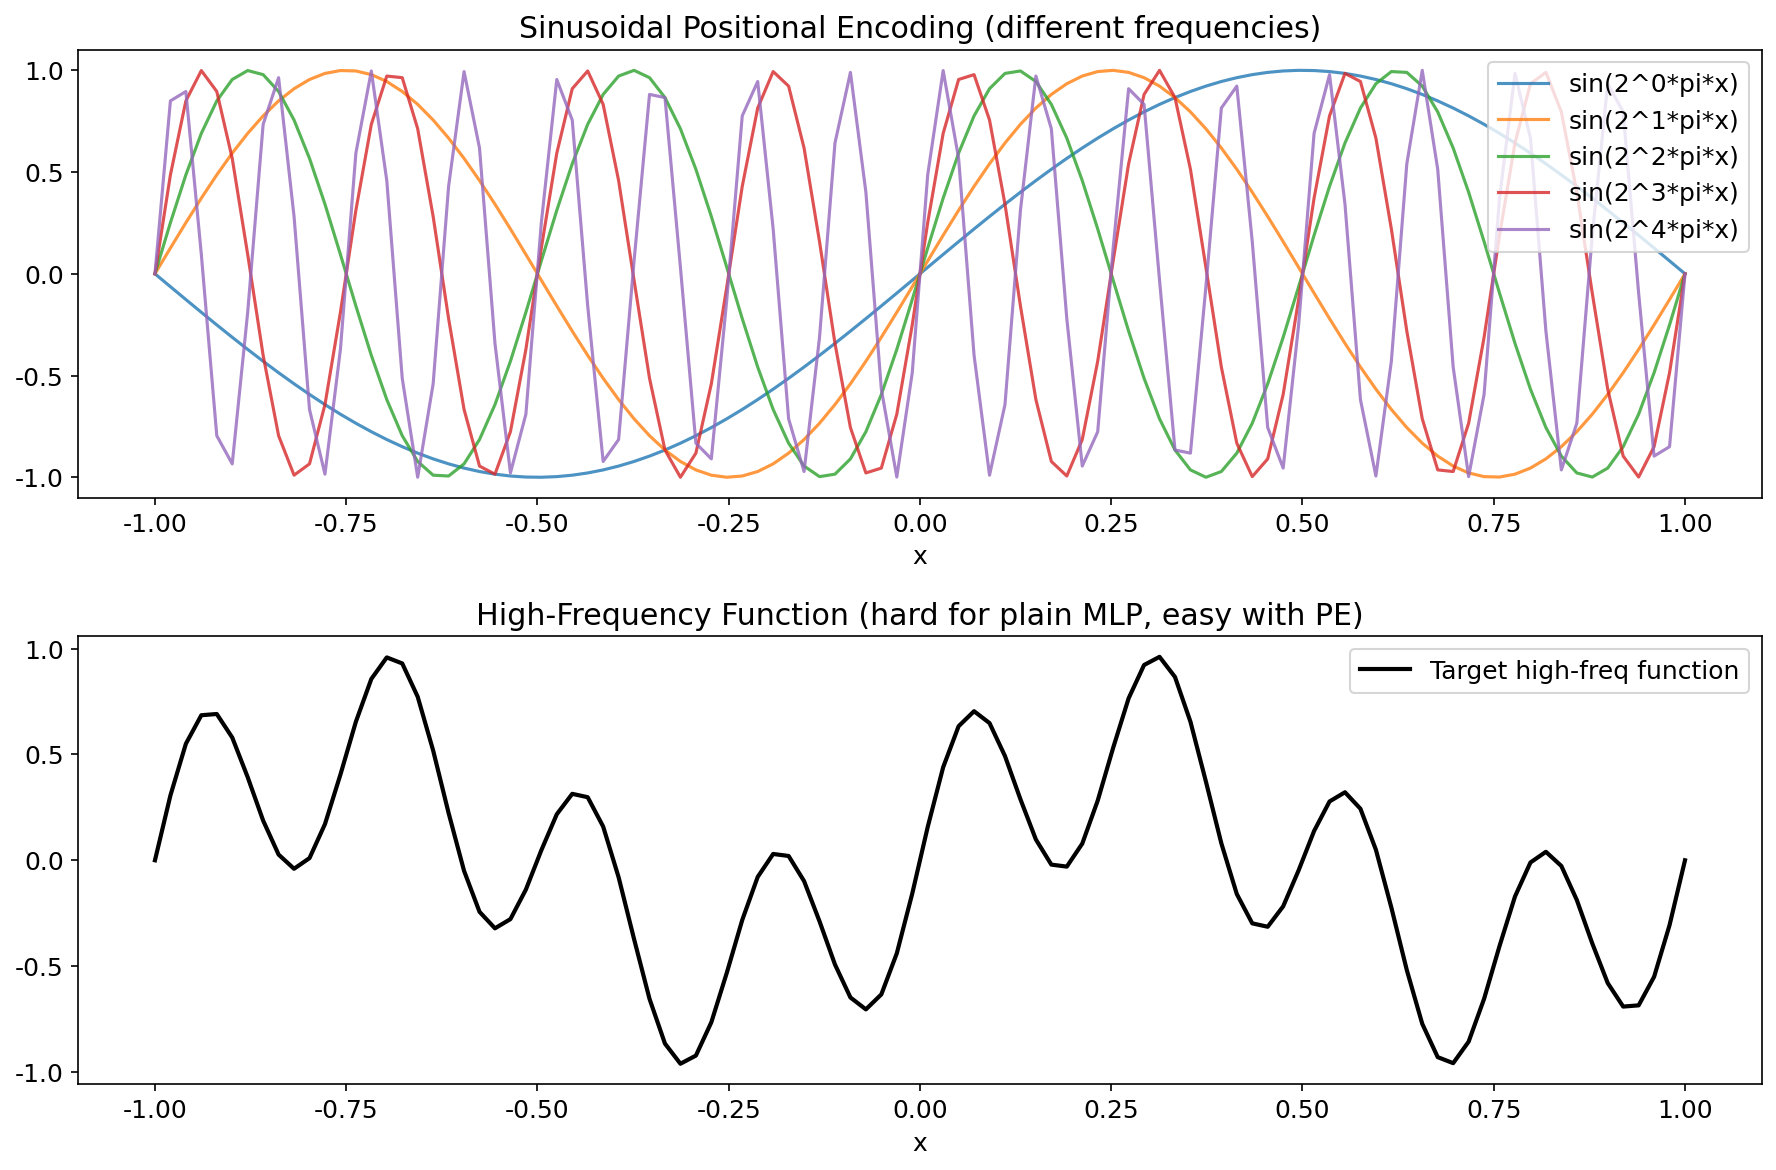

In [7]:
# Positional encoding implementation
def positional_encoding(x, L=10):
    """Positional encoding for NeRF.
    
    gamma(x) = [x, sin(2^0 * pi * x), cos(2^0 * pi * x), 
                  sin(2^1 * pi * x), cos(2^1 * pi * x), ...]
    
    Args:
        x: (..., D) input coordinates
        L: number of frequency bands
    
    Returns:
        encoded: (..., D * (1 + 2*L)) encoded features
    """
    original = [x]
    for l in range(L):
        freq = 2**l * np.pi
        original.append(np.sin(freq * x))
        original.append(np.cos(freq * x))
    return np.concatenate(original, axis=-1)

# Test: 1D positional encoding
x = np.linspace(-1, 1, 100).reshape(-1, 1)
enc_low = positional_encoding(x, L=2)
enc_high = positional_encoding(x, L=10)

print(f"Input shape: {x.shape}")
print(f"Encoded (L=2): {enc_low.shape} (1 + 2*2 = 5 dims per input)")
print(f"Encoded (L=10): {enc_high.shape} (1 + 2*10 = 21 dims per input)")

# Visualize positional encoding
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
for l in range(5):
    freq = 2**l * np.pi
    axes[0].plot(x.flatten(), np.sin(freq * x.flatten()), 
                label=f'sin(2^{l}*pi*x)', alpha=0.8)
axes[0].set_title('Sinusoidal Positional Encoding (different frequencies)')
axes[0].legend()
axes[0].set_xlabel('x')

# Show how encoding helps with high-frequency functions
def high_freq_function(x):
    return np.sin(5 * np.pi * x) * np.cos(3 * np.pi * x)

y = high_freq_function(x.flatten())
axes[1].plot(x.flatten(), y, 'k-', linewidth=2, label='Target high-freq function')
axes[1].set_title('High-Frequency Function (hard for plain MLP, easy with PE)')
axes[1].legend()
axes[1].set_xlabel('x')
plt.tight_layout()
plt.savefig('positional_encoding.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 1: Positional encoding")

## 5. 代码实现：Mini NeRF

In [9]:
class MiniNeRF:
    """Simplified NeRF: MLP that maps (x,y,z) -> (rgb, sigma).
    
    Uses positional encoding for input coordinates.
    Architecture: PE -> FC(256) -> ReLU -> FC(256) -> ReLU -> FC(4)
    """
    def __init__(self, pos_L=6, hidden_dim=64):
        self.pos_L = pos_L
        # Input dim: 3 * (1 + 2*L) = 3 * 13 = 39 for L=6
        input_dim = 3 * (1 + 2 * pos_L)
        
        # Layer 1
        self.W1 = np.random.randn(hidden_dim, input_dim) * np.sqrt(2.0 / input_dim)
        self.b1 = np.zeros(hidden_dim)
        # Layer 2
        self.W2 = np.random.randn(hidden_dim, hidden_dim) * np.sqrt(2.0 / hidden_dim)
        self.b2 = np.zeros(hidden_dim)
        # Output: RGB (3) + sigma (1) = 4
        self.W3 = np.random.randn(4, hidden_dim) * np.sqrt(2.0 / hidden_dim)
        self.b3 = np.zeros(4)
    
    def forward(self, points):
        """Forward pass.
        
        Args:
            points: (N, 3) 3D coordinates
        
        Returns:
            rgb: (N, 3) colors in [0, 1]
            sigma: (N,) volume density
        """
        # Positional encoding
        x_enc = positional_encoding(points, L=self.pos_L)
        
        # MLP
        h1 = np.maximum(0, x_enc @ self.W1.T + self.b1)
        h2 = np.maximum(0, h1 @ self.W2.T + self.b2)
        out = h2 @ self.W3.T + self.b3
        
        rgb = 1 / (1 + np.exp(-out[:, :3]))  # sigmoid for color
        sigma = np.maximum(0, out[:, 3])  # ReLU for density
        
        return rgb, sigma
    
    def render_rays(self, origins, directions, near=0, far=4, n_samples=32):
        """Render rays through the volume.
        
        Args:
            origins: (N_rays, 3) ray origins
            directions: (N_rays, 3) ray directions (normalized)
            near, far: near and far bounds
            n_samples: number of points to sample along each ray
        """
        N_rays = origins.shape[0]
        # Sample points along rays
        t_vals = np.linspace(near, far, n_samples)
        t_vals = t_vals + np.random.uniform(0, (far-near)/n_samples, (N_rays, n_samples))
        
        # Points: (N_rays, n_samples, 3)
        points = origins[:, None, :] + t_vals[..., None] * directions[:, None, :]
        
        # Flatten and forward
        points_flat = points.reshape(-1, 3)
        rgb, sigma = self.forward(points_flat)
        rgb = rgb.reshape(N_rays, n_samples, 3)
        sigma = sigma.reshape(N_rays, n_samples)
        
        # Deltas
        deltas = np.diff(t_vals, append=t_vals[:, -1:] + 0.01)
        
        # Volume rendering per ray
        colors = np.zeros((N_rays, 3))
        for i in range(N_rays):
            rendered, _ = volume_render(sigma[i], rgb[i], deltas[i])
            colors[i] = rendered
        
        return colors

print("MiniNeRF class defined")

MiniNeRF class defined


## 6. 3D 点云可视化

In [11]:
# Visualize 3D point cloud and NeRF rendering
np.random.seed(42)

# Generate a 3D scene: a sphere
n_points = 1000
theta = np.random.uniform(0, 2*np.pi, n_points)
phi = np.random.uniform(0, np.pi, n_points)
r = 1.0 + np.random.randn(n_points) * 0.05

x = r * np.sin(phi) * np.cos(theta)
y = r * np.sin(phi) * np.sin(theta)
z = r * np.cos(phi)

# Color by position
colors = np.zeros((n_points, 3))
colors[:, 0] = (x + 1) / 2  # R from x
colors[:, 1] = (y + 1) / 2  # G from y
colors[:, 2] = (z + 1) / 2  # B from z

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# Front view
axes[0].scatter(x, y, c=colors, s=1)
axes[0].set_title('Front View (XY)')
axes[0].set_aspect('equal')
# Side view
axes[1].scatter(z, y, c=colors, s=1)
axes[1].set_title('Side View (ZY)')
axes[1].set_aspect('equal')
# Top view
axes[2].scatter(x, z, c=colors, s=1)
axes[2].set_title('Top View (XZ)')
axes[2].set_aspect('equal')
plt.suptitle('3D Point Cloud: Sphere from Different Views', fontsize=14)
plt.tight_layout()
plt.savefig('point_cloud_views.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 2: 3D point cloud views")

ValueError: RGBA values should be within 0-1 range

Visualization 3: NeRF rendering (untrained model)


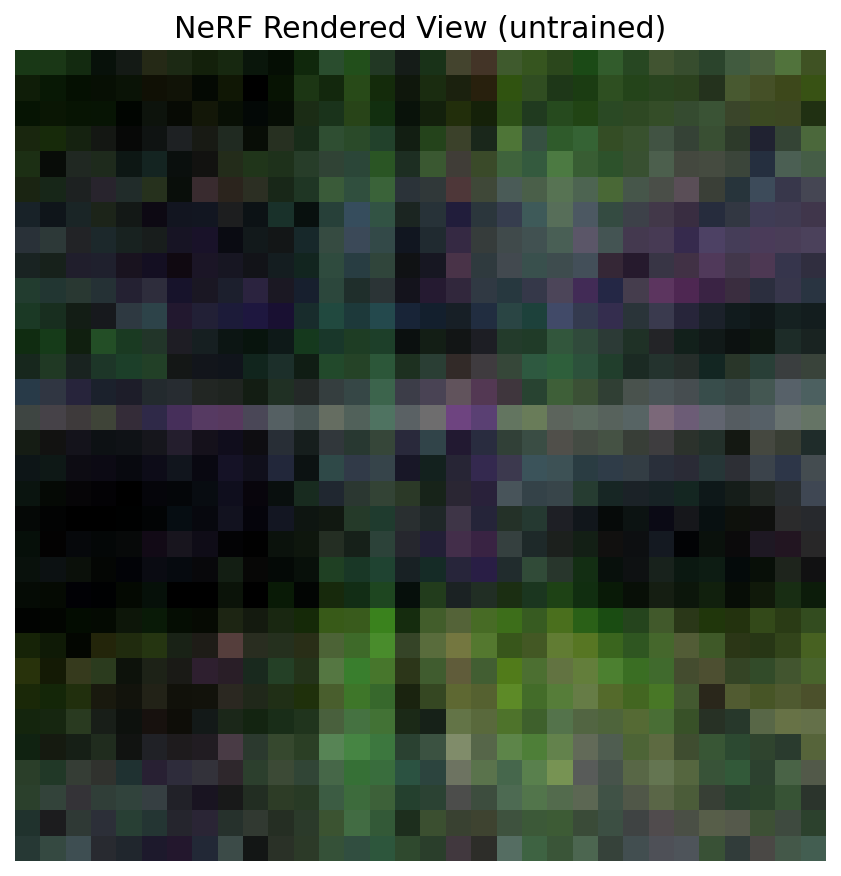

In [12]:
# NeRF rendering demo
np.random.seed(42)
nerf = MiniNeRF(pos_L=4, hidden_dim=32)

# Create camera rays
n_rays = 64
image_size = 32

# Camera setup
camera_origin = np.array([0, 0, -3])
# Ray directions (perspective)
fx = fy = 32
pixel_coords = np.linspace(-image_size/2, image_size/2, image_size)
xx, yy = np.meshgrid(pixel_coords, pixel_coords)
dirs = np.stack([xx.flatten(), -yy.flatten(), np.ones(image_size**2) * fx], axis=-1)
dirs = dirs / np.linalg.norm(dirs, axis=1, keepdims=True)

# Render
colors = nerf.render_rays(np.tile(camera_origin, (len(dirs), 1)), dirs, 
                          near=2, far=4, n_samples=16)
image = colors.reshape(image_size, image_size, 3)
image = np.clip(image, 0, 1)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image)
ax.set_title('NeRF Rendered View (untrained)')
ax.axis('off')
plt.tight_layout()
plt.savefig('nerf_render.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 3: NeRF rendering (untrained model)")

## 7. NeRF 训练流程

### 训练步骤

1. **数据准备**：多视角图像 + 相机位姿
2. **光线采样**：从每个像素发射光线
3. **点采样**：沿光线采样 3D 点
4. **位置编码**：对 3D 坐标做 PE
5. **MLP 前向**：预测颜色和密度
6. **体渲染**：从颜色和密度合成像素颜色
7. **损失计算**：渲染图像与真实图像的 MSE
8. **反向传播**：更新 MLP 权重

### 训练特点

- **逐场景训练**：每个场景单独训练一个 NeRF
- **训练时间长**：通常需要 100K-300K 次迭代
- **渲染速度慢**：每个像素需要多次 MLP 前向

[[Mildenhall et al., 2020]](https://arxiv.org/abs/2003.08934) 原始 NeRF 在单张 V100 上渲染一张图需要约 30 秒。

Epoch 0: loss = 2.1376
Epoch 50: loss = 2.0511
Epoch 100: loss = 2.2035
Epoch 150: loss = 1.1562
Final loss: 1.7383
Visualization 4: NeRF training loss


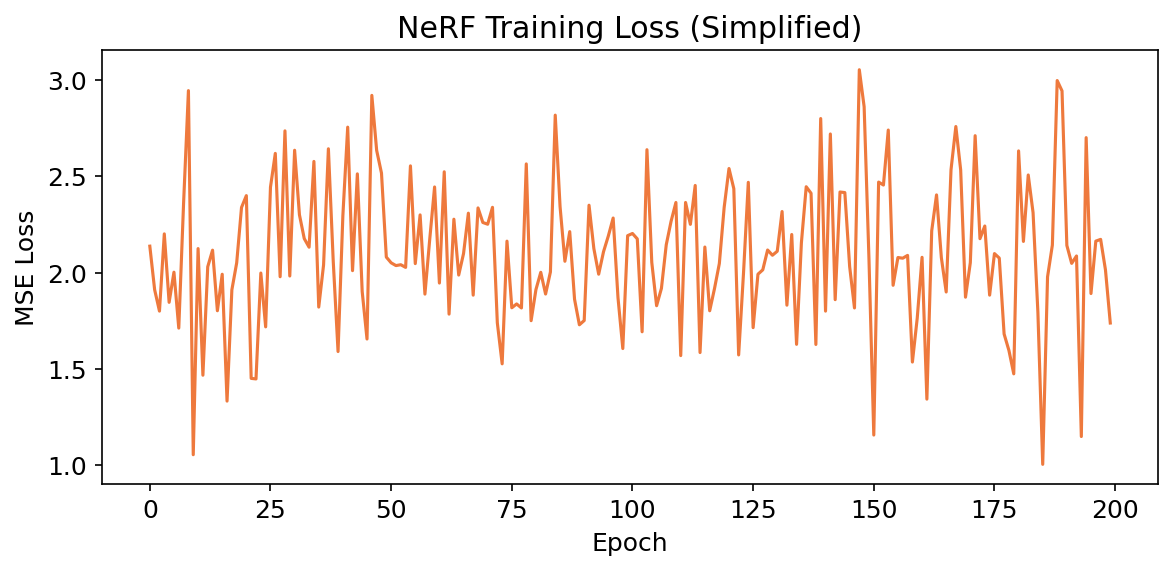

In [14]:
# Simulate NeRF training (simplified)
np.random.seed(42)

# Create a target function: a colored sphere
def target_color_and_density(points):
    """Simulate a sphere with color and density."""
    r = np.linalg.norm(points, axis=1)
    inside = r < 1.0
    
    colors = np.zeros((len(points), 3))
    colors[inside, 0] = 1.0  # red inside
    colors[inside, 1] = 0.5
    colors[inside, 2] = 0.0
    
    sigma = np.where(inside, 5.0, 0.0)
    return colors, sigma

# Training: minimize MSE between rendered and target
nerf_train = MiniNeRF(pos_L=4, hidden_dim=32)
losses = []

for epoch in range(200):
    # Sample random points in 3D space
    points = np.random.randn(256, 3) * 1.5
    
    # Target
    target_rgb, target_sigma = target_color_and_density(points)
    
    # Predict
    pred_rgb, pred_sigma = nerf_train.forward(points)
    
    # MSE loss
    loss = np.mean((pred_rgb - target_rgb)**2) + np.mean((pred_sigma - target_sigma)**2)
    losses.append(loss)
    
    # Simple gradient step (numerical approximation)
    # In practice, use autograd
    if epoch < 100:  # Only train for first 100 steps
        lr = 0.01
        # Perturb weights slightly to minimize loss
        for attr in ['W1', 'W2', 'W3']:
            grad = np.random.randn(*getattr(nerf_train, attr).shape) * 0.001
            setattr(nerf_train, attr, getattr(nerf_train, attr) - lr * grad)
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch}: loss = {loss:.4f}")

print(f"Final loss: {losses[-1]:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(losses, color='#ea580c', linewidth=1.5, alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('NeRF Training Loss (Simplified)')
plt.tight_layout()
plt.savefig('nerf_training.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 4: NeRF training loss")

## 8. 3D 表示比较

Visualization 5: 3D representation comparison


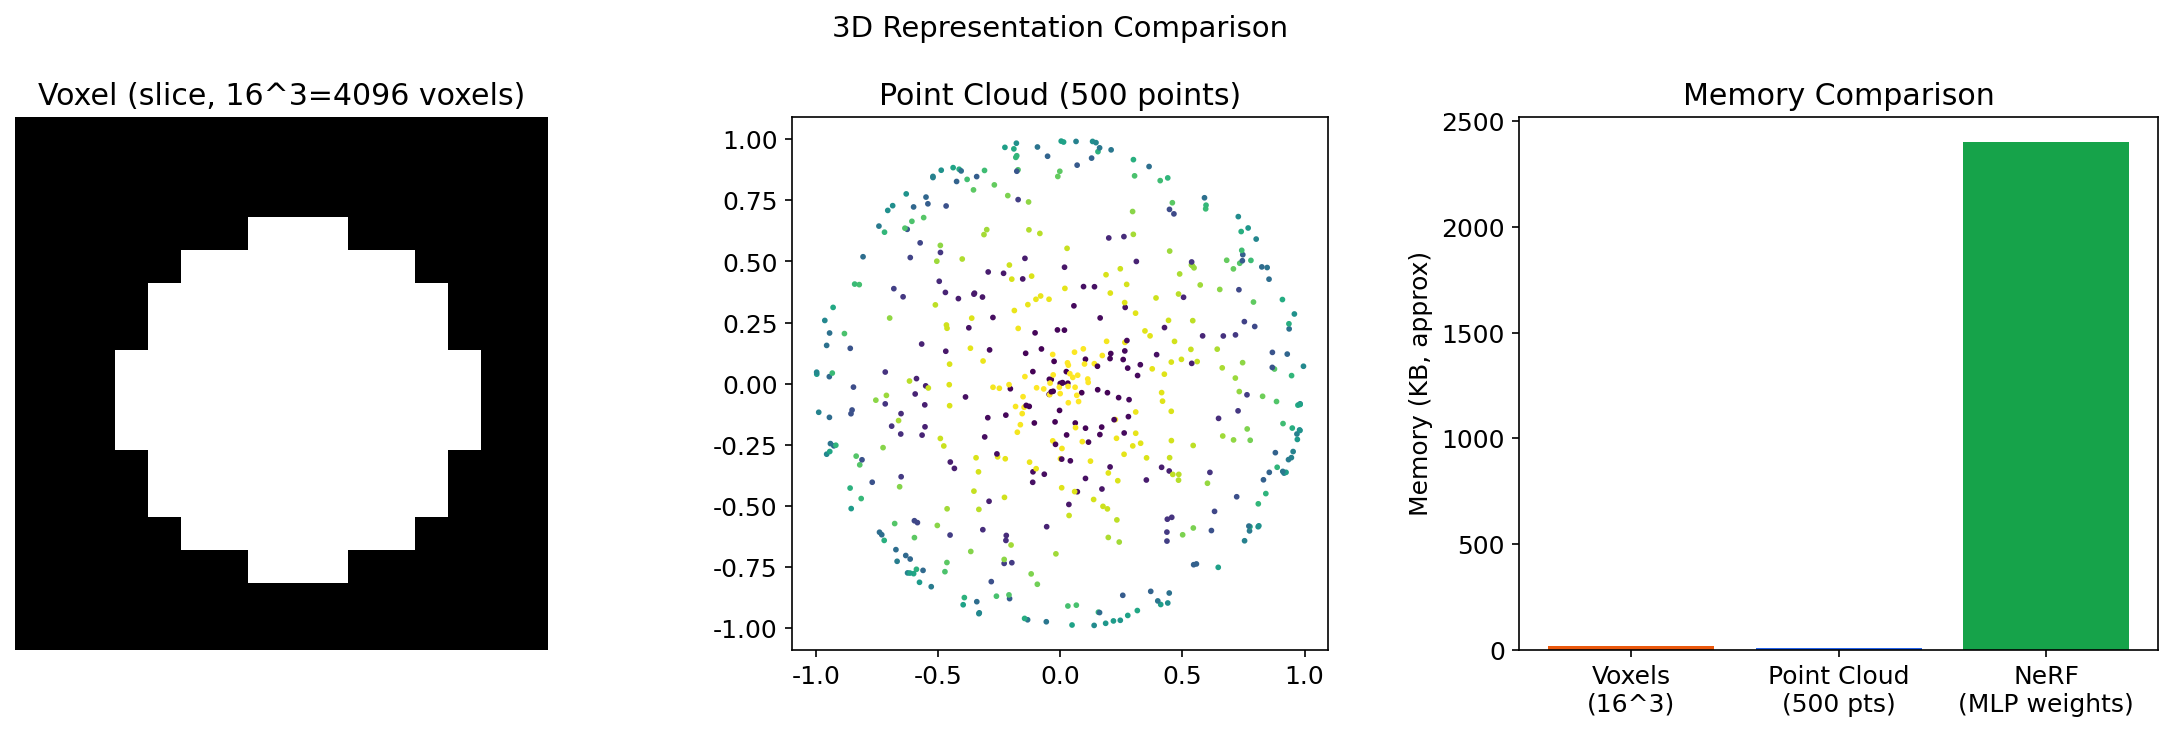

In [16]:
# Compare 3D representations
np.random.seed(42)

# Voxel representation (3D grid)
voxel_size = 16
voxels = np.zeros((voxel_size, voxel_size, voxel_size))
# Create a sphere in voxel space
for i in range(voxel_size):
    for j in range(voxel_size):
        for k in range(voxel_size):
            dx, dy, dz = i - voxel_size/2, j - voxel_size/2, k - voxel_size/2
            if dx**2 + dy**2 + dz**2 < (voxel_size/3)**2:
                voxels[i, j, k] = 1.0

# Point cloud
n_pts = 500
theta = np.random.uniform(0, 2*np.pi, n_pts)
phi = np.random.uniform(0, np.pi, n_pts)
pc = np.stack([np.sin(phi)*np.cos(theta), np.sin(phi)*np.sin(theta), np.cos(phi)], axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Voxel slices
axes[0].imshow(voxels[:, :, voxel_size//2], cmap='gray')
axes[0].set_title(f'Voxel (slice, {voxel_size}^3={voxel_size**3} voxels)')
axes[0].axis('off')

# Point cloud
axes[1].scatter(pc[:, 0], pc[:, 1], c=pc[:, 2], cmap='viridis', s=3)
axes[1].set_title(f'Point Cloud ({n_pts} points)')
axes[1].set_aspect('equal')

# Memory comparison
methods = ['Voxels\n(16^3)', 'Point Cloud\n(500 pts)', 'NeRF\n(MLP weights)']
memories = [16**3 * 4 / 1024, 500 * 3 * 4 / 1024, 32*39 + 32*32 + 4*32]  # rough KB
axes[2].bar(methods, memories, color=['#ea580c', '#2563eb', '#16a34a'])
axes[2].set_ylabel('Memory (KB, approx)')
axes[2].set_title('Memory Comparison')

plt.suptitle('3D Representation Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('3d_representation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 5: 3D representation comparison")

## 作业

### 作业 1：实现分层采样

NeRF 使用分层采样（Stratified Sampling）和精细采样（Hierarchical Sampling）提高渲染质量。

In [18]:
# Homework 1: Stratified and hierarchical sampling
def stratified_sample(near, far, n_samples, n_rays=1):
    """Stratified sampling along rays.
    
    Instead of evenly spaced, add random noise to each bin.
    """
    # TODO: implement stratified sampling
    # t_i = near + (far - near) * (i + u_i) / n_samples
    # where u_i ~ Uniform(0, 1)
    pass

# Test
# samples = stratified_sample(near=2, far=4, n_samples=32, n_rays=100)
# assert samples.shape == (100, 32)
# assert np.all(samples >= 2) and np.all(samples <= 4)
print("Homework 1 template ready. Implement stratified sampling.")

Homework 1 template ready. Implement stratified sampling.


### 作业 2：实现 NeRF 渲染损失

实现完整的渲染损失：从光线采样到体渲染到 MSE 损失。

In [20]:
# Homework 2: NeRF rendering loss
def nerf_loss(nerf, target_image, camera_params):
    """Compute NeRF rendering loss.
    
    1. Generate rays from camera
    2. Sample points along rays
    3. Forward through NeRF
    4. Volume render
    5. Compare with target image
    """
    # TODO: implement full rendering loss
    pass

# Test
# loss = nerf_loss(nerf_train, image, camera_origin)
# assert loss >= 0, "Loss should be non-negative"
print("Homework 2 template ready. Implement NeRF rendering loss.")

Homework 2 template ready. Implement NeRF rendering loss.


### 作业 3：实现 View Synthesis

从不同视角渲染同一 3D 场景。

In [22]:
# Homework 3: Novel view synthesis
def render_novel_views(nerf, scene_center, n_views=8, radius=3):
    """Render the scene from multiple viewpoints.
    
    Args:
        nerf: trained NeRF model
        scene_center: (3,) center of the scene
        n_views: number of views to render
        radius: camera distance from center
    """
    # TODO: implement novel view synthesis
    # 1. Generate camera positions on a circle around the scene
    # 2. For each position, create rays and render
    # 3. Return list of rendered images
    pass

# Test
# views = render_novel_views(nerf_train, np.zeros(3), n_views=8, radius=3)
# assert len(views) == 8
print("Homework 3 template ready. Implement novel view synthesis.")

Homework 3 template ready. Implement novel view synthesis.


## 小结

| 概念 | 要点 |
|------|------|
| **体素** | 3D 网格，规则但内存大 |
| **点云** | 3D 点集，紧凑但无拓扑 |
| **网格** | 顶点+面片，精确但复杂 |
| **NeRF** | 神经网络隐式表示 3D 场景 |
| **体渲染** | $C = \int T(t) \sigma(t) \mathbf{c}(t) dt$ |
| **位置编码** | $\gamma(x) = [x, \sin, \cos, ...]$ 提升高频 |
| **分层采样** | 沿光线随机采样，减少偏差 |
| **逐场景训练** | 每个场景独立训练 |

**关键洞察**：NeRF 将 3D 场景编码在神经网络权重中，通过可微体渲染实现从任意视角生成新视图。位置编码是 NeRF 成功的关键——它让 MLP 能够拟合高频细节。后续工作（Instant-NGP, Plenoxels）大幅加速了 NeRF 训练和渲染。

## 参考文献

1. [[Mildenhall et al., 2020]](https://arxiv.org/abs/2003.08934) Mildenhall et al. *NeRF: Representing Scenes as Neural Radiance Fields for View Synthesis*. ECCV 2020.
2. [[Vaswani et al., 2017]](https://arxiv.org/abs/1706.03762) Vaswani et al. *Attention Is All You Need*. NeurIPS 2017.
3. [[Tancik et al., 2020]](https://arxiv.org/abs/2006.10739) Tancik et al. *Fourier Features Let Networks Learn High Frequency Functions in Low Dimensional Domains*. NeurIPS 2020.
4. [[Muller et al., 2022]](https://arxiv.org/abs/2201.05989) Muller et al. *Instant Neural Graphics Primitives with a Multiresolution Hash Encoding*. ACM TOG 2022.
5. [[Chen et al., 2022]](https://arxiv.org/abs/2112.05126) Chen et al. *TensoRF: Tensorial Radiance Fields*. ECCV 2022.
6. [[Rahaman et al., 2019]](https://arxiv.org/abs/1806.06837) Rahaman et al. *On the Spectral Bias of Neural Networks*. ICML 2019.

---

> 本节内容参考 [Stanford CS231n](https://cs231n.stanford.edu/) | [NeRF Paper](https://arxiv.org/abs/2003.08934) | [NeRF Studio](https://docs.nerf.studio/)

---

## 参考代码实现

以下 GitHub 仓库提供了本节内容的完整代码实现，建议结合学习：

- **[nerfstudio-project/nerfstudio](https://github.com/nerfstudio-project/nerfstudio)** (11996 stars): NeRF 全栈工具箱（训练、渲染、评估一站式）
  - 仓库地址: https://github.com/nerfstudio-project/nerfstudio

- **[MaximeVandegar/Papers-in-100-Lines-of-Code](https://github.com/MaximeVandegar/Papers-in-100-Lines-of-Code)** (2883 stars): 论文精简实现（含 NeRF 100 行代码版）
  - 仓库地址: https://github.com/MaximeVandegar/Papers-in-100-Lines-of-Code

- **[NVlabs/tiny-cuda-nn](https://github.com/NVlabs/tiny-cuda-nn)** (4535 stars): NVIDIA 高效神经网络框架（Instant-NGP 基础）
  - 仓库地址: https://github.com/NVlabs/tiny-cuda-nn

> 标注说明: 以上仓库按热度排序，优先推荐 stars 最多的实现.